In [1]:
import openeo

connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


In [2]:
aoi = {
    "type": "Polygon",
    # Paste koordinat yang didapat 
    "coordinates":
        [
            [
              117.58812764552601,
              4.133326974398287
            ],
            [
              117.75161907303544,
              4.133326974398287
            ],
            [
              117.75161907303544,
              3.971832859595736
            ],
            [
              117.58812764552601,
              3.971832859595736
            ],
            [
              117.58812764552601,
              4.133326974398287
            ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-10-01", "2026-06-01"],
    spatial_extent={
        "west": 117.58812764552601,
        "south": 3.971832859595736,
        "east": 117.75161907303544,
        "north": 4.133326974398287
    },
    # Disesuaikan dengan data yang dibutuhkan
    bands=["SO2"],
)

# Agregasi harian agar tidak ada lebih dari satu data per hari
s5p_no2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Agregasi spasial untuk menghasilkan rata-rata time series per AOI
s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(reducer="mean", geometries=aoi)

In [3]:
job = s5post.execute_batch(title="NO2 in Nunukan", outputfile="NO2DiNunukan.nc")

0:00:00 Job 'j-2609091506094232b76c75cac52968e8': send 'start'


0:00:04 Job 'j-2609091506094232b76c75cac52968e8': queued (progress 0%)


0:00:10 Job 'j-2609091506094232b76c75cac52968e8': queued (progress 0%)


0:00:18 Job 'j-2609091506094232b76c75cac52968e8': queued (progress 0%)


0:00:26 Job 'j-2609091506094232b76c75cac52968e8': queued (progress 0%)


In [7]:
job = s5post.execute_batch(title="CO in Nunukan", outputfile="CODiNunukan.nc")

0:00:00 Job 'j-26082816452642eb97708cfc27871111': send 'start'
0:00:03 Job 'j-26082816452642eb97708cfc27871111': queued (progress 0%)
0:00:09 Job 'j-26082816452642eb97708cfc27871111': queued (progress 0%)
0:00:15 Job 'j-26082816452642eb97708cfc27871111': queued (progress 0%)
0:00:23 Job 'j-26082816452642eb97708cfc27871111': queued (progress 0%)
0:00:33 Job 'j-26082816452642eb97708cfc27871111': queued (progress 0%)
0:00:46 Job 'j-26082816452642eb97708cfc27871111': queued (progress 0%)
0:01:02 Job 'j-26082816452642eb97708cfc27871111': running (progress N/A)
0:01:21 Job 'j-26082816452642eb97708cfc27871111': running (progress N/A)
0:01:45 Job 'j-26082816452642eb97708cfc27871111': running (progress N/A)
0:02:15 Job 'j-26082816452642eb97708cfc27871111': running (progress N/A)
0:02:53 Job 'j-26082816452642eb97708cfc27871111': running (progress N/A)
0:03:40 Job 'j-26082816452642eb97708cfc27871111': finished (progress 100%)


In [9]:
job = s5post.execute_batch(title="SO2 in Nunukan", outputfile="SO2DiNunukan.nc")

0:00:00 Job 'j-2608281659564944a512b72ca6580a13': send 'start'
0:00:03 Job 'j-2608281659564944a512b72ca6580a13': queued (progress 0%)
0:00:08 Job 'j-2608281659564944a512b72ca6580a13': queued (progress 0%)
0:00:15 Job 'j-2608281659564944a512b72ca6580a13': queued (progress 0%)
0:00:23 Job 'j-2608281659564944a512b72ca6580a13': queued (progress 0%)
0:00:33 Job 'j-2608281659564944a512b72ca6580a13': queued (progress 0%)
0:00:46 Job 'j-2608281659564944a512b72ca6580a13': queued (progress 0%)
0:01:01 Job 'j-2608281659564944a512b72ca6580a13': queued (progress 0%)
0:01:21 Job 'j-2608281659564944a512b72ca6580a13': queued (progress 0%)
0:01:45 Job 'j-2608281659564944a512b72ca6580a13': running (progress N/A)
0:02:15 Job 'j-2608281659564944a512b72ca6580a13': running (progress N/A)
0:02:53 Job 'j-2608281659564944a512b72ca6580a13': running (progress N/A)
0:03:40 Job 'j-2608281659564944a512b72ca6580a13': finished (progress 100%)


In [6]:
import numpy as np
import pandas as pd
import netCDF4

file_path = "NO2DiNunukan.nc"
ds = netCDF4.Dataset(file_path)

# Ambil NO2 sebagai masked array, lalu ubah data kosong (masked) jadi NaN
no2 = ds.variables["NO2"][:]
no2 = np.ma.filled(no2, np.nan)

# Ambil Time
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time  # fallback jika tidak ada units

new_dates = []
new_no2 = []

for i in range(len(dates)):
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)

    daily_data = no2[i]
    if np.all(np.isnan(daily_data)):
        # Kalau seluruh data hari itu kosong, hasilnya NaN
        new_no2.append(np.nan)
    else:
        # np.nanmean mengabaikan NaN saat menghitung rata-rata
        new_no2.append(np.nanmean(daily_data))

df = pd.DataFrame({
    "date": new_dates,
    "NO2": new_no2
})

# Simpan ke CSV (NaN otomatis ditulis sebagai kosong/"" oleh pandas)
df.to_csv("NO2_Nunukan_timeseries.csv", index=False)

In [8]:
import numpy as np
import pandas as pd
import netCDF4

file_path = "SO2DiNunukan.nc"
ds = netCDF4.Dataset(file_path)

# Ambil SO2 sebagai masked array, lalu ubah data kosong (masked) jadi NaN
so2 = ds.variables["SO2"][:]
so2 = np.ma.filled(so2, np.nan)

# Ambil Time
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time  # fallback jika tidak ada units

new_dates = []
new_so2 = []

for i in range(len(dates)):
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)

    daily_data = so2[i]
    if np.all(np.isnan(daily_data)):
        # Kalau seluruh data hari itu kosong, hasilnya NaN
        new_so2.append(np.nan)
    else:
        # np.nanmean mengabaikan NaN saat menghitung rata-rata
        new_so2.append(np.nanmean(daily_data))

df = pd.DataFrame({
    "date": new_dates,
    "SO2": new_so2
})

# Simpan ke CSV (NaN otomatis ditulis sebagai kosong/"" oleh pandas)
df.to_csv("SO2_Nunukan_timeseries.csv", index=False)

In [9]:
import numpy as np
import pandas as pd
import netCDF4

file_path = "CODiNunukan.nc"
ds = netCDF4.Dataset(file_path)

# Ambil CO sebagai masked array, lalu ubah data kosong (masked) jadi NaN
co = ds.variables["CO"][:]
co = np.ma.filled(co, np.nan)

# Ambil Time
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time  # fallback jika tidak ada units

new_dates = []
new_co = []

for i in range(len(dates)):
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)

    daily_data = co[i]
    if np.all(np.isnan(daily_data)):
        # Kalau seluruh data hari itu kosong, hasilnya NaN
        new_co.append(np.nan)
    else:
        # np.nanmean mengabaikan NaN saat menghitung rata-rata
        new_co.append(np.nanmean(daily_data))

df = pd.DataFrame({
    "date": new_dates,
    "CO": new_co
})

# Simpan ke CSV (NaN otomatis ditulis sebagai kosong/"" oleh pandas)
df.to_csv("CO_Nunukan_timeseries.csv", index=False)

c:\Users\Admin\AppData\Local\Programs\Python\Python39\lib\site-packages\matplotlib\cbook.py:1398: UserWarning: Warning: converting a masked element to nan.
  return np.asarray(x, float)


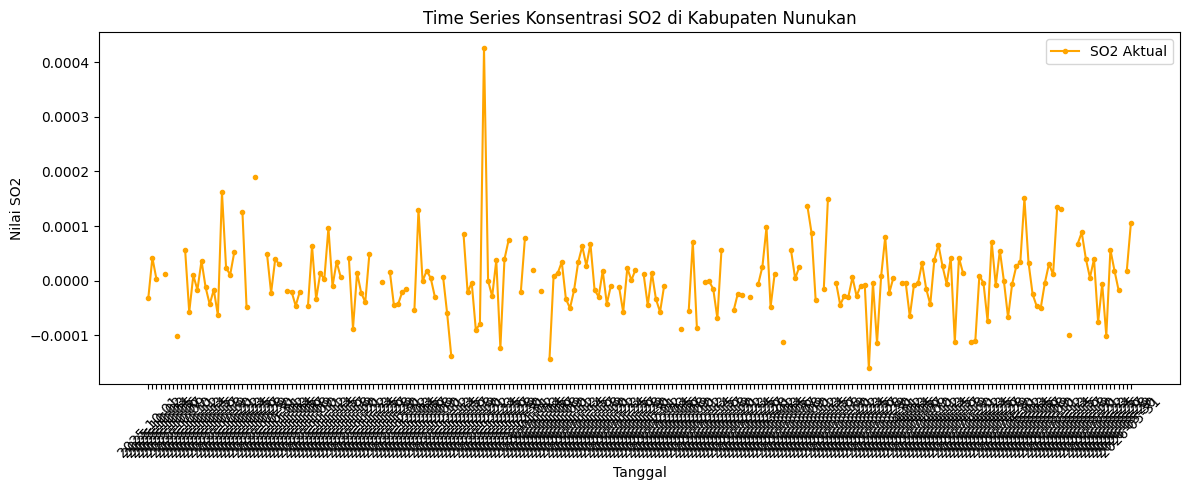

In [1]:
import pandas as pd
import netCDF4
import numpy as np
import matplotlib.pyplot as plt

# --- 1. PROSES EKSTRAKSI DATA ---
file_path = "SO2DiNunukan.nc"
ds = netCDF4.Dataset(file_path)

# Ambil SO2 dan Time
so2 = ds.variables["SO2"][:]
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time  # fallback jika tidak ada units

new_dates = []
new_so2 = [] # Ubah nama variabel agar konsisten

for i in range(len(dates)):
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)
    # Ganti no2[i] menjadi so2[i]
    new_so2.append(np.mean(so2[i]))

# Buat DataFrame dan simpan ke CSV
df = pd.DataFrame({
    "date": new_dates,
    "SO2": new_so2
})
df.to_csv("SO2_Nunukan_timeseries.csv", index=False)


# --- 2. PROSES PEMBUATAN GRAFIK ---
plt.figure(figsize=(12, 5)) # Diperlebar agar tanggal tidak terlalu berdempetan

# Plot data tanggal di sumbu X dan nilai SO2 di sumbu Y
plt.plot(df["date"], df["SO2"], label="SO2 Aktual", color="orange", marker=".", linewidth=1.5)

plt.title("Time Series Konsentrasi SO2 di Kabupaten Nunukan")
plt.xlabel("Tanggal")
plt.ylabel("Nilai SO2")

# Merotasi label tanggal di sumbu X agar mudah dibaca dan tidak bertumpuk
plt.xticks(rotation=45)
plt.tight_layout() # Memastikan label bawah tidak terpotong saat ditampilkan

plt.legend()
plt.show()

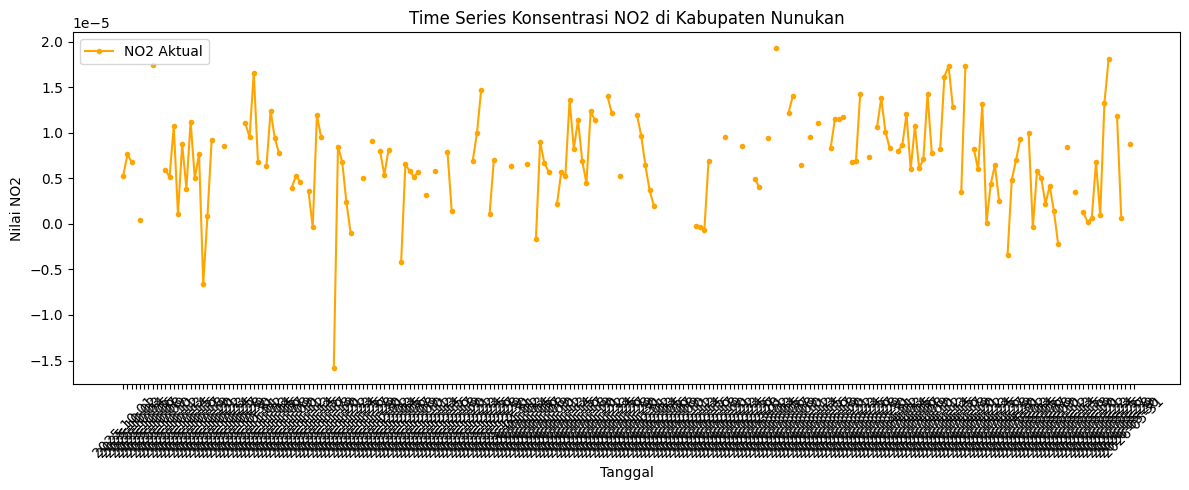

In [3]:
import pandas as pd
import netCDF4
import numpy as np
import matplotlib.pyplot as plt

# --- 1. PROSES EKSTRAKSI DATA ---
file_path = "NO2DiNunukan.nc"
ds = netCDF4.Dataset(file_path)

# Ambil NO2 dan Time
no2 = ds.variables["NO2"][:]
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time  # fallback jika tidak ada units

new_dates = []
new_no2 = [] # Ubah nama variabel agar konsisten

for i in range(len(dates)):
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)
    # Ganti no2[i] menjadi so2[i]
    new_no2.append(np.mean(no2[i]))

# Buat DataFrame dan simpan ke CSV
df = pd.DataFrame({
    "date": new_dates,
    "NO2": new_no2
})
df.to_csv("NO2_Nunukan_timeseries.csv", index=False)


# --- 2. PROSES PEMBUATAN GRAFIK ---
plt.figure(figsize=(12, 5)) # Diperlebar agar tanggal tidak terlalu berdempetan

# Plot data tanggal di sumbu X dan nilai NO2 di sumbu Y
plt.plot(df["date"], df["NO2"], label="NO2 Aktual", color="orange", marker=".", linewidth=1.5)

plt.title("Time Series Konsentrasi NO2 di Kabupaten Nunukan")
plt.xlabel("Tanggal")
plt.ylabel("Nilai NO2")

# Merotasi label tanggal di sumbu X agar mudah dibaca dan tidak bertumpuk
plt.xticks(rotation=45)
plt.tight_layout() # Memastikan label bawah tidak terpotong saat ditampilkan

plt.legend()
plt.show()

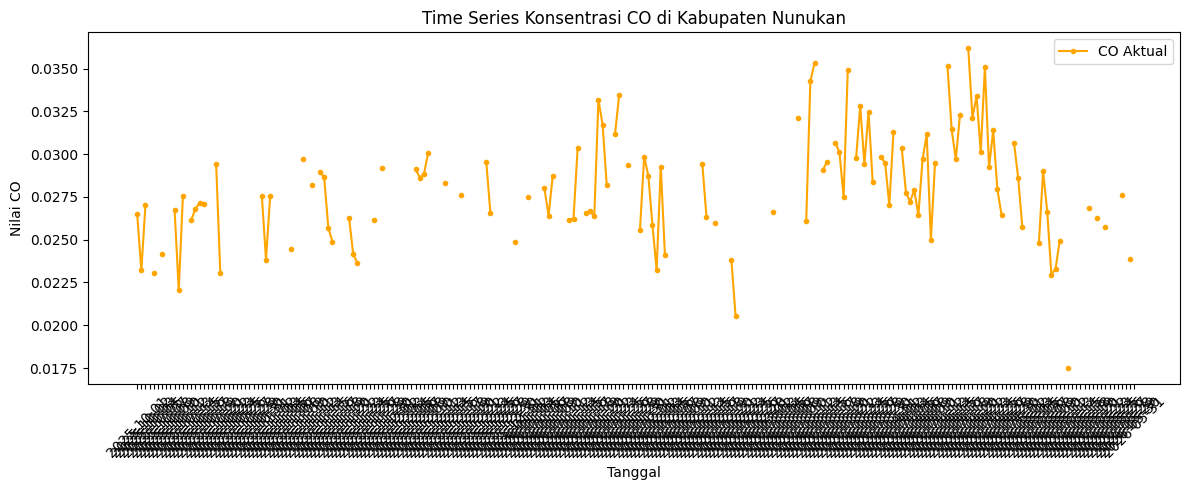

In [5]:
import pandas as pd
import netCDF4
import numpy as np
import matplotlib.pyplot as plt

# --- 1. PROSES EKSTRAKSI DATA ---
file_path = "CODiNunukan.nc"
ds = netCDF4.Dataset(file_path)

# Ambil COD dan Time
co = ds.variables["CO"][:]
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time  # fallback jika tidak ada units

new_dates = []
new_co = [] # Ubah nama variabel agar konsisten

for i in range(len(dates)):
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)
    # Ganti no2[i] menjadi so2[i]
    new_co.append(np.mean(co[i]))

# Buat DataFrame dan simpan ke CSV
df = pd.DataFrame({
    "date": new_dates,
    "CO": new_co
})
df.to_csv("CO_Nunukan_timeseries.csv", index=False)


# --- 2. PROSES PEMBUATAN GRAFIK ---
plt.figure(figsize=(12, 5)) # Diperlebar agar tanggal tidak terlalu berdempetan

# Plot data tanggal di sumbu X dan nilai CO di sumbu Y
plt.plot(df["date"], df["CO"], label="CO Aktual", color="orange", marker=".", linewidth=1.5)

plt.title("Time Series Konsentrasi CO di Kabupaten Nunukan")
plt.xlabel("Tanggal")
plt.ylabel("Nilai CO")

# Merotasi label tanggal di sumbu X agar mudah dibaca dan tidak bertumpuk
plt.xticks(rotation=45)
plt.tight_layout() # Memastikan label bawah tidak terpotong saat ditampilkan

plt.legend()
plt.show()

In [11]:
import pandas as pd

df = pd.read_csv("CO_Nunukan_Timeseries.csv")
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2025-08-25"
end_date   = "2026-08-25"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 125
Daftar tanggal missing:
DatetimeIndex(['2025-08-25', '2025-08-26', '2025-08-27', '2025-08-28',
               '2025-08-29', '2025-08-30', '2025-08-31', '2025-09-01',
               '2025-09-02', '2025-09-03',
               ...
               '2026-08-16', '2026-08-17', '2026-08-18', '2026-08-19',
               '2026-08-20', '2026-08-21', '2026-08-22', '2026-08-23',
               '2026-08-24', '2026-08-25'],
              dtype='datetime64[ns]', length=125, freq=None)


In [12]:
import pandas as pd

df = pd.read_csv("SO2_Nunukan_Timeseries.csv")
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2025-08-25"
end_date   = "2026-08-25"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 125
Daftar tanggal missing:
DatetimeIndex(['2025-08-25', '2025-08-26', '2025-08-27', '2025-08-28',
               '2025-08-29', '2025-08-30', '2025-08-31', '2025-09-01',
               '2025-09-02', '2025-09-03',
               ...
               '2026-08-16', '2026-08-17', '2026-08-18', '2026-08-19',
               '2026-08-20', '2026-08-21', '2026-08-22', '2026-08-23',
               '2026-08-24', '2026-08-25'],
              dtype='datetime64[ns]', length=125, freq=None)


In [13]:
import pandas as pd

df = pd.read_csv("NO2_Nunukan_Timeseries.csv")
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2025-08-25"
end_date   = "2026-08-25"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 125
Daftar tanggal missing:
DatetimeIndex(['2025-08-25', '2025-08-26', '2025-08-27', '2025-08-28',
               '2025-08-29', '2025-08-30', '2025-08-31', '2025-09-01',
               '2025-09-02', '2025-09-03',
               ...
               '2026-08-16', '2026-08-17', '2026-08-18', '2026-08-19',
               '2026-08-20', '2026-08-21', '2026-08-22', '2026-08-23',
               '2026-08-24', '2026-08-25'],
              dtype='datetime64[ns]', length=125, freq=None)


In [14]:
df = pd.read_csv("CO_Nunukan_Timeseries.csv")
missing_value = df['CO'].isna().sum()
print(missing_value)

118


In [15]:
df = pd.read_csv("NO2_Nunukan_Timeseries.csv")
missing_value = df['NO2'].isna().sum()
print(missing_value)

87


In [17]:
df = pd.read_csv("SO2_Nunukan_Timeseries.csv")
missing_value = df['SO2'].isna().sum()
print(missing_value)

44


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

df = pd.read_csv("CO_Nunukan_Timeseries.csv")
df_clean = df.dropna(subset=['CO']).copy()

df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean = df_clean.sort_values('date').reset_index(drop=True)

model = IsolationForest(contamination=0.05, random_state=42)  # contamination 0.05 = 5%
pred = model.fit_predict(df_clean[['CO']])

# Tambahkan hasil prediksi ke dataframe
df_clean['anomaly'] = pred  # -1 = outlier, 1 = normal

# Nilai -1 merepresentasikan outlier
outliers_if = df_clean[df_clean['anomaly'] == -1]
jumlah_outlier = len(outliers_if)
print("Jumlah outlier:", jumlah_outlier)
print(outliers_if[['date', 'CO']].head())

Jumlah outlier: 7
         date        CO
6  2025-10-12  0.022047
65 2026-02-23  0.020537
69 2026-03-13  0.034267
70 2026-03-14  0.035311
76 2026-03-22  0.034897


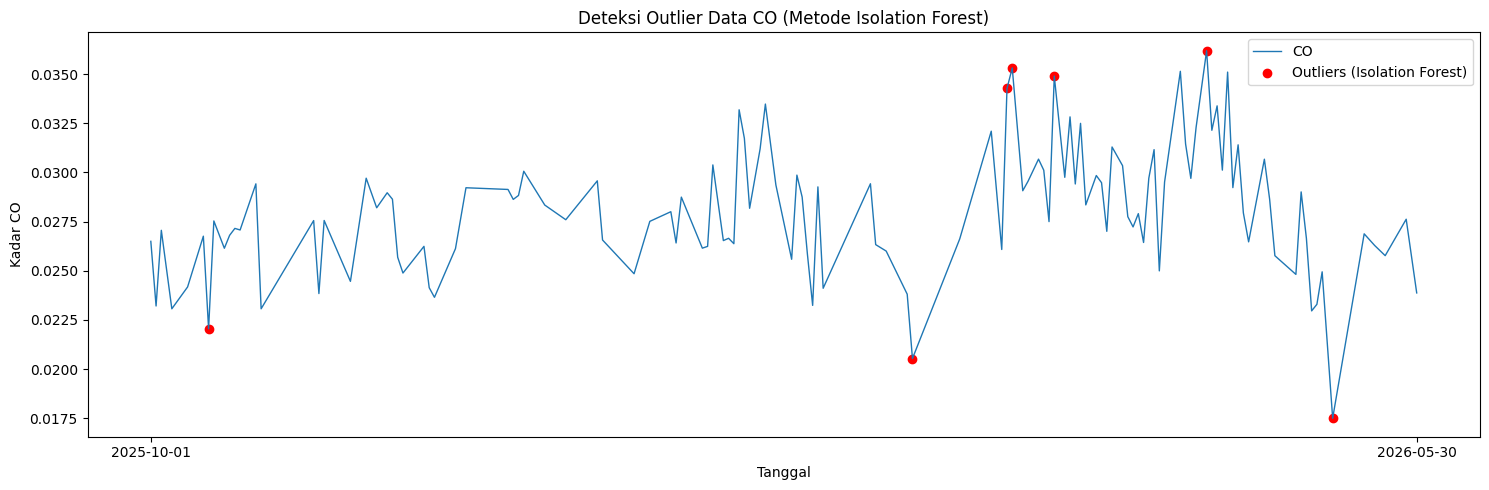

In [20]:
# Visualisasi
plt.figure(figsize=(15, 5))
plt.plot(df_clean['date'], df_clean['CO'], label="CO", linewidth=1)
plt.scatter(outliers_if['date'], outliers_if['CO'],
            color='red', marker='o', label="Outliers (Isolation Forest)")
plt.title("Deteksi Outlier Data CO (Metode Isolation Forest)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar CO")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df_clean['date'].iloc[0], df_clean['date'].iloc[-1]],
    labels=[df_clean['date'].iloc[0].strftime('%Y-%m-%d'),
            df_clean['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

df = pd.read_csv("SO2_Nunukan_Timeseries.csv")
df_clean = df.dropna(subset=['SO2']).copy()

df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean = df_clean.sort_values('date').reset_index(drop=True)

model = IsolationForest(contamination=0.05, random_state=42)  # contamination 0.05 = 5%
pred = model.fit_predict(df_clean[['SO2']])

# Tambahkan hasil prediksi ke dataframe
df_clean['anomaly'] = pred  # -1 = outlier, 1 = normal

# Nilai -1 merepresentasikan outlier
outliers_if = df_clean[df_clean['anomaly'] == -1]
jumlah_outlier = len(outliers_if)
print("Jumlah outlier:", jumlah_outlier)
print(outliers_if[['date', 'SO2']].head())

Jumlah outlier: 10
         date       SO2
14 2025-10-20  0.000162
20 2025-10-28  0.000190
58 2025-12-15 -0.000138
64 2025-12-23  0.000426
68 2025-12-27 -0.000123


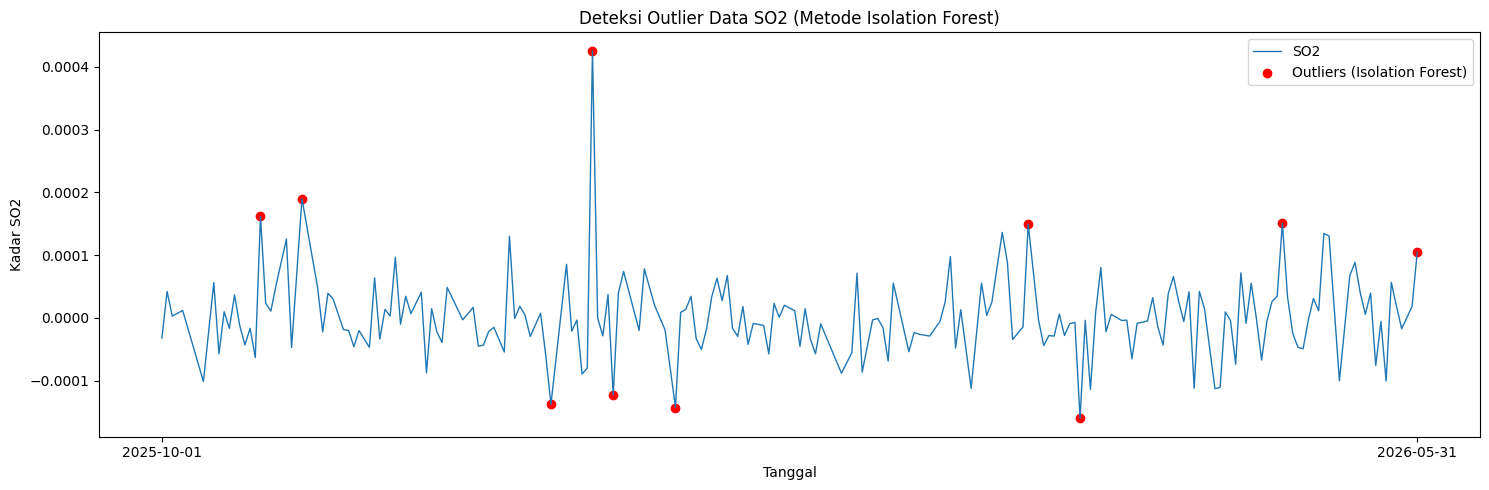

In [23]:
# Visualisasi
plt.figure(figsize=(15, 5))
plt.plot(df_clean['date'], df_clean['SO2'], label="SO2", linewidth=1)
plt.scatter(outliers_if['date'], outliers_if['SO2'],
            color='red', marker='o', label="Outliers (Isolation Forest)")
plt.title("Deteksi Outlier Data SO2 (Metode Isolation Forest)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar SO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df_clean['date'].iloc[0], df_clean['date'].iloc[-1]],
    labels=[df_clean['date'].iloc[0].strftime('%Y-%m-%d'),
            df_clean['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

df = pd.read_csv("NO2_Nunukan_Timeseries.csv")
df_clean = df.dropna(subset=['NO2']).copy()

df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean = df_clean.sort_values('date').reset_index(drop=True)

model = IsolationForest(contamination=0.05, random_state=42)  # contamination 0.05 = 5%
pred = model.fit_predict(df_clean[['NO2']])

# Tambahkan hasil prediksi ke dataframe
df_clean['anomaly'] = pred  # -1 = outlier, 1 = normal

# Nilai -1 merepresentasikan outlier
outliers_if = df_clean[df_clean['anomaly'] == -1]
jumlah_outlier = len(outliers_if)
print("Jumlah outlier:", jumlah_outlier)
print(outliers_if[['date', 'NO2']].head())

Jumlah outlier: 8
         date       NO2
14 2025-10-20 -0.000007
20 2025-11-02  0.000017
33 2025-11-21 -0.000016
43 2025-12-07 -0.000004
90 2026-03-06  0.000019


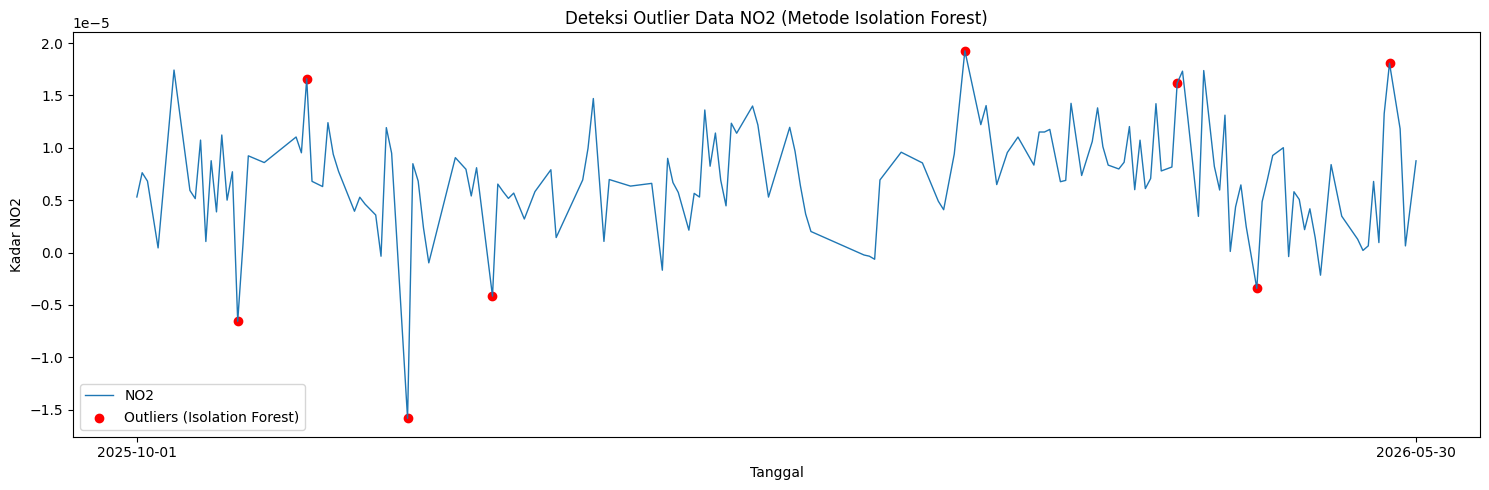

In [25]:
# Visualisasi
plt.figure(figsize=(15, 5))
plt.plot(df_clean['date'], df_clean['NO2'], label="NO2", linewidth=1)
plt.scatter(outliers_if['date'], outliers_if['NO2'],
            color='red', marker='o', label="Outliers (Isolation Forest)")
plt.title("Deteksi Outlier Data NO2 (Metode Isolation Forest)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df_clean['date'].iloc[0], df_clean['date'].iloc[-1]],
    labels=[df_clean['date'].iloc[0].strftime('%Y-%m-%d'),
            df_clean['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

In [74]:
import pandas as pd

df_co = pd.read_csv("CO_Nunukan_Timeseries.csv")
df_no2 = pd.read_csv("NO2_Nunukan_Timeseries.csv")
df_so2 = pd.read_csv("SO2_Nunukan_Timeseries.csv")

dataframe_merged = pd.DataFrame({
    "date": df_co['date'],
    "CO": df_co['CO'],
    "NO2": df_no2['NO2'],
    "SO2": df_so2['SO2']
})

dataframe_merged.to_csv("Polutan_Nunukan.csv", index=False)

In [16]:
import pandas as pd
import numpy as np
import tsfel

# 1. Load data
df = pd.read_csv("data_kualitas_udara_sample20.csv")
kolom_polutan = ["CO", "SO2", "NO2", "PM2.5", "PM10", "O3"]

# 2. Definisikan 14 fitur statistik & temporal yang dipilih dari TSFEL
#    (statistical + temporal domain, cocok untuk data pendek 20 titik)
fitur_terpilih = {
    "statistical": [
        "Mean",
        "Median",
        "Standard deviation",
        "Variance",
        "Skewness",
        "Kurtosis",
        "Root mean square",
        "Max",
        "Min",
        "Interquartile range",
    ],
    "temporal": [
        "Mean absolute diff",
        "Mean diff",
        "Slope",
        "Zero crossing rate",
    ],
}

# 3. Ambil konfigurasi default TSFEL lalu filter hanya 14 fitur di atas
cfg = tsfel.get_features_by_domain()

nama_fitur_dipilih = set(fitur_terpilih["statistical"] + fitur_terpilih["temporal"])
for domain in list(cfg.keys()):
    for nama_fitur in list(cfg[domain].keys()):
        if nama_fitur not in nama_fitur_dipilih:
            del cfg[domain][nama_fitur]
    if len(cfg[domain]) == 0:
        del cfg[domain]

# 4. Ekstraksi fitur untuk tiap kolom polutan (masing-masing dianggap 1 sinyal time series)
hasil_semua = []
for kolom in kolom_polutan:
    sinyal = df[kolom].values
    fitur_df = tsfel.time_series_features_extractor(
        cfg, sinyal, fs=1, verbose=0
    )
    fitur_df.insert(0, "variabel", kolom)
    hasil_semua.append(fitur_df)

hasil_akhir = pd.concat(hasil_semua, ignore_index=True)

# 5. Simpan hasil
hasil_akhir.to_csv("fitur_tsfel_hasil.csv", index=False)

print(f"Jumlah fitur yang diekstrak: {hasil_akhir.shape[1] - 1}")
print(hasil_akhir)

ModuleNotFoundError: No module named 'tsfel'